# NWI-IBC046: Image Analysis Report

---

<div style="display: flex; align-items: center; justify-content: space-between; margin-bottom: 1em;">
  <h1 style="margin: 0; font-weight: bold; font-size: 2.2em;">Retinal Blood Vessel Segmentation</h1>
  <img src="https://www.ru.nl/sites/default/files/styles/content_full/public/2023-10/RU_drupal_logo_RU_0.png.webp?itok=m6D0pAxp" 
       alt="Radboud University Logo" 
       style="height: 220px; width: auto; max-width: 800px;" />
</div>

---

<div style="display: flex; justify-content: space-between; align-items: flex-start; margin-top: 1.5em;">

  <div style="width: 60%; font-size: 1.1em; line-height: 1.6;">
    <strong>Simon Wagener</strong><br>
    <a href="mailto:simon.wagener@ru.nl" style="color: #004C97; text-decoration: none;">simon.wagener@ru.nl</a><br>
    Under the supervision of prof. dr. Geert Litjens<br>
    This report is the product of the course <a href="https://ru.osiris-student.nl/onderwijscatalogus/extern/cursus?cursuscode=NWI-IBC046&collegejaar=2024" style="color: #004C97; text-decoration: underline;">NWI-IBC046 Image Analysis</a>
  </div>

  <div style="width: 35%; text-align: right; font-size: 1.1em; color: #555; font-style: italic;">
    Date: 10-07-2025
  </div>

</div>

---

1. [Introduction](#introduction)
    - [Approach](#approach)
        - [Image Processing Pipeline](#image-processing-pipeline)
        - [Bayesian Optimization](#bayesian-optimization)
2. [Methods](#methods)
    - [Dependencies](#dependencies)
    - [Custom Functions](#custom-functions)
    - [Running](#running)
3. [Results](#results)
4. [Discussion](#discussion)
5. [References](#references)

# Introduction
Retinal blood vessel segmentation is a critical preprocessing step in the analysis of fundus images for the extraction of vascular features such as vessel length, width, tortuosity, branching structure, and bifurcation angles. These features serve as important biomarkers for diagnosing a variety of ocular and systemic conditions, including diabetic retinopathy, hypertensive retinopathy, and retinal artery occlusion. Traditionally, the segmentation of blood vessels in retinal images is carried out manually by trained experts, a process that is time-consuming, labor-intensive, and subject to inter-observer variability. Consequently, there is significant interest in developing automated methods for retinal vessel segmentation that can provide accurate and consistent results with minimal human intervention. And finally, the segmentation algorithm will be assessed how well it performs compared to manually segmented blood vessels.

## Approach
The proposed approach utilizes a dataset comprising 20 retinal images, each accompanied by a corresponding circular mask delineating the region of interest, and 20 ground truth binary vessel segmentation images annotated manually. The goal is to design a modular image processing pipeline, whose parameters can be optimized using Bayesian optimization. This approach allows for flexible adaptation to different performance metrics, such as the area under the receiver operating characteristic curve (AUC-ROC), the Dice similarity coefficient, or pixel-wise classification accuracy.

<div style="text-align: left;">
  <img src="https://raw.githubusercontent.com/Dimon821/image-analysis-of-retinal-blood-vessels/refs/heads/main/img/overview.jpg" alt="Overview" style="width: 100%; max-width: 1000px;">
  <span style="color:black">Schematic overview of the processing pipeline.</span><br><br>
</div>

### Image Processing Pipeline
The proposed image processing pipeline for retinal blood vessel segmentation begins with the extraction of the green channel from each RGB fundus image, as blood vessels exhibit the highest contrast against the retinal background in this channel. To further enhance vessel visibility, contrast stretching is applied, thereby expanding the dynamic range of pixel intensities and improving the distinction between vascular and non-vascular regions.

Due to uneven illumination often present in retinal images, background intensity variations can obscure vessel structures. To mitigate this, a Gaussian filter is used to estimate the background illumination, which is subsequently subtracted from the contrast-enhanced image. The result is then inverted, enhancing vessel-like structures and preparing the image for robust edge detection.

Edge detection is carried out using an algorithm such as the Canny edge detector, which is effective in capturing strong intensity gradients typically associated with blood vessel boundaries. However, this method can also highlight non-vessel structures, particularly at the periphery of the retinal image where the outer mask introduces high-contrast edges. To eliminate these false positives, the circular boundary of the retina is identified using a Hough transform, and all pixels outside this region are suppressed, ensuring that only the retinal area is processed further.

To reduce noise and eliminate small, irrelevant structures mistakenly detected as vessels, a median filter is applied. This non-linear filter is particularly effective at removing isolated pixels and small artifacts without significantly affecting vessel continuity. Following noise reduction, morphological closing is performed to reconnect any fragmented vessel segments, enhancing the continuity of the vascular network.

Connected component analysis is then employed, with a filtering step that retains only the largest connected component, which is assumed to correspond to the primary vessel structure. Despite these preprocessing steps, bright circular artifacts often appear in the center of the image due to camera reflections or illumination irregularities. These artifacts are detected through an additional Hough transform combined with edge detection. Once identified, their radii are slightly expanded, and the corresponding ring-shaped regions are removed from the image to prevent interference with the segmentation process.

In the final stage, a second morphological closing operation is applied, and once more, only the largest connected component is retained. The central circular region, previously removed to eliminate artifacts, is then reintroduced to maintain the anatomical integrity of the retina in the final segmented output.

This sequence of operations constitutes a modular and parameterized pipeline, suitable for automated retinal vessel segmentation. The parameters of each stage can be fine-tuned using Bayesian optimization, allowing for flexible adaptation to different evaluation metrics such as AUC-ROC, Dice coefficient, or pixel-wise accuracy.

### Bayesian Optimization
To optimize the performance of the retinal vessel segmentation pipeline, a Bayesian optimization framework was employed using Gaussian Process-based minimization. The objective was to maximize the segmentation quality as measured by the Area Under the Receiver Operating Characteristic Curve (AUC-ROC), which evaluates the alignment between the predicted vessel maps and the manually segmented ground truth images.

The optimization process targets a set of 15 parameters that control various aspects of the pipeline, including Gaussian smoothing scales, edge detection thresholds, morphological filtering settings, and geometric constraints for masking and artifact removal. These parameters define a multi-dimensional search space, with each dimension bounded by a plausible range based on prior domain knowledge.

The optimization begins by randomly sampling a number of initial parameter sets to explore the search space. For each parameter combination, the segmentation pipeline is executed on the training dataset. The output vessel maps are then compared against the ground truth using the compute_auc function, which flattens and concatenates the predicted and true binary masks before computing the AUC score via roc_auc_score. A negative AUC is returned as the objective value to conform to the minimization strategy of the optimizer.

To prevent excessive evaluations and overfitting, an early stopping mechanism is integrated via a custom EarlyStopper class. This class monitors the optimization progress and halts the search if no improvement in AUC is observed over a predefined number of iterations (patience). If triggered, the optimization is terminated early with the best parameter set found up to that point.

Throughout the optimization, the best AUC score and the corresponding parameter configuration are tracked using a mutable dictionary object. This allows for detailed logging of the optimization trajectory, including identification of new optima and a running summary of the best performance achieved.

After a total of 50 calls (or earlier if stopped), the optimization concludes, and the optimal parameter set—i.e., the one that yielded the highest AUC—is reported. This final configuration is then used for subsequent analysis and evaluation of the segmentation performance.

This Bayesian optimization framework provides a flexible and efficient means of tuning the pipeline's parameters in a data-driven manner, ensuring robust segmentation performance without manual intervention.



[1,2]

# Methods

The retinal image dataset can be found at https://drive.grand-challenge.org/ .

## Dependencies

In [2]:
# Standard Libraries
import os
import re
import inspect
import concurrent
from typing import Iterable, List
from concurrent.futures import ThreadPoolExecutor
import concurrent

# Data Analysis
import pandas as pd
import numpy as np

# Scientific Computing
from scipy.ndimage import binary_closing, gaussian_filter, median_filter

# Image Processing & Visualization
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Scikit-Image
from skimage import img_as_float
from skimage.color import gray2rgb
from skimage.draw import circle_perimeter, disk
from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.morphology import square, disk as sk_disk

# Machine Learning & Optimization
from sklearn.metrics import roc_auc_score
from skopt import gp_minimize
from skopt.space import Real, Integer


## Custom Functions

### Loading and Showing Images

In [3]:
supported_exts = ('.tif', '.tiff', '.gif')

def image_iterator(
    images,
    func,
    condition=lambda img: True,
    max_workers=4,
    **kwargs
):
    """
    Applies a function to a list of images in parallel with optional filtering and kwargs.

    Parameters:
    - images: list of numpy arrays
    - func: function to apply. Must accept (img, **kwargs)
    - condition: function to filter valid images (e.g., lambda img: img.ndim == 2)
    - max_workers: int, number of threads
    - kwargs: additional keyword arguments; can be constants or lists of same length as images

    Returns:
    - List of processed images
    """
    if not isinstance(images, list) or len(images) == 0:
        return []

    # Prepare per-image argument dicts
    param_dicts = []
    for i in range(len(images)):
        param = {
            key: (val[i] if isinstance(val, list) else val)
            for key, val in kwargs.items()
        }
        param_dicts.append(param)

    def ensure_array(obj):
        if isinstance(obj, np.ndarray):
            return obj
        if isinstance(obj, (list, tuple)) and isinstance(obj[0], np.ndarray):
            return obj[0]
        return np.zeros_like(images[0])  # fallback to dummy array

    def process_single(img, param):
        if not condition(img):
            return img
        try:
            result = func(img, **param)
            return ensure_array(result)
        except Exception as e:
            print(f"[image_iterator] Error: {e}")
            return np.zeros_like(img)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_single, images, param_dicts))

    return results

class ImageFolderCollection:
    
    def __init__(self, root, folders, keywords, extensions=None):
        self.root = root
        self.folders = folders
        self.keywords = keywords
        self.extensions = extensions or supported_exts
        self.data = {}

    def collect_images(self):
        for folder in self.folders:
            for keyword in self.keywords:
                path = os.path.join(self.root, folder, keyword)
                key = f"{folder}_{keyword}"
                if os.path.exists(path) and os.path.isdir(path):
                    images = [
                        os.path.join(path, f)
                        for f in os.listdir(path)
                        if os.path.isfile(os.path.join(path, f)) and f.lower().endswith(self.extensions)
                    ]
                    self.data[key] = images
                else:
                    self.data[key] = []

    def print_summary(self):
        for key, paths in self.data.items():
            print(f"{key}: {len(paths)} images")

    def load_images(self, folder, keyword):
        image_dict = {}
        key = f"{folder}_{keyword}"
        for full_path in self.data.get(key, []):
            try:
                img = Image.open(full_path)
                ext = os.path.splitext(full_path)[1].lower()
                if ext in ['.tif', '.tiff']:
                    img = img.convert("RGB")
                elif ext == '.gif':
                    img = img.convert("L")
                else:
                    img = img.convert("L")

                filename = os.path.basename(full_path)
                match = re.match(r"(\d+)_", filename)
                if match:
                    image_id = match.group(1)  # e.g., '21'
                    image_dict[image_id] = np.array(img)
                else:
                    print(f"Filename does not match expected pattern: {filename}")
            except Exception as e:
                print(f"Failed to load image {full_path}: {e}")
        return image_dict


    def show_images(self, images, image_names, cols=5, max_images=5, title="Images"):
        if max_images:
            images = images[:max_images]
            image_names = image_names[:max_images]

        n = len(images)
        if n == 0:
            print("No images to display.")
            return

        print(f"Displaying images: {title}")

        rows = (n + cols - 1) // cols
        plt.figure(figsize=(15, 5 * rows))

        for i, img in enumerate(images):
            ax = plt.subplot(rows, cols, i + 1)
            cmap = "gray" if img.ndim == 2 else None
            ax.imshow(img, cmap=cmap)
            # Add enumeration index before image name, 0-indexed
            ax.set_title(f"{i}: {image_names[i]}", pad=2)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

def generate_error_overlay(pred_masks, true_masks, threshold=0.5, printout = False):
    """
    Generates colorblind-friendly RGB overlays and prints segmentation statistics.

    Colors:
    - True Positives (TP): Blue
    - False Positives (FP): Magenta
    - False Negatives (FN): Orange
    - True Negatives (TN): Dark Gray

    Parameters:
    - pred_masks: list of predicted binary or soft masks
    - true_masks: list of ground truth binary or soft masks
    - threshold: binarization threshold

    Returns:
    - List of RGB uint8 overlays
    """
    import numpy as np

    overlays = []

    total_tp = total_fp = total_fn = total_tn = 0

    for pred, gt in zip(pred_masks, true_masks):
        assert pred.shape == gt.shape, "Shape mismatch"

        pred_bin = (pred >= threshold).astype(np.uint8)
        gt_bin = (gt >= threshold).astype(np.uint8)

        # Compute masks
        tp = (pred_bin == 1) & (gt_bin == 1)
        fp = (pred_bin == 1) & (gt_bin == 0)
        fn = (pred_bin == 0) & (gt_bin == 1)
        tn = (pred_bin == 0) & (gt_bin == 0)

        # Update totals
        total_tp += tp.sum()
        total_fp += fp.sum()
        total_fn += fn.sum()
        total_tn += tn.sum()

        # Create overlay image
        overlay = np.zeros((*pred.shape, 3), dtype=np.uint8)
        overlay[tp] = [0, 114, 178]     # Blue
        overlay[fp] = [204, 121, 167]   # Magenta
        overlay[fn] = [230, 159, 0]     # Orange
        overlay[tn] = [50, 50, 50]      # Dark Gray

        overlays.append(overlay)

    # Compute metrics
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    accuracy  = (total_tp + total_tn) / (total_tp + total_fp + total_fn + total_tn)
    f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    iou       = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0

    total_pixels = total_tp + total_fp + total_fn + total_tn
    total_on = total_tp + total_fp
    total_off = total_fn + total_tn
    on_percentage = 100.0 * total_on / total_pixels

    if printout:
        print(f"Threshold: {threshold}")
        print(f"Total TP: {total_tp}")
        print(f"Total FP: {total_fp}")
        print(f"Total FN: {total_fn}")
        print(f"Total TN: {total_tn}")
        print()
        print(f"False Positive Rate (FPR): {total_fp/(total_fp+total_tn):.4f}")
        print(f"False Negative Rate (FNR): {total_fn / (total_fn + total_tp):.4f}")
        print()
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-score: {f1_score:.4f}")
        print(f"IoU: {iou:.4f}")
        print({
            'total_on': total_on,
            'total_off': total_off,
            'total_pixels': total_pixels,
            'total_on_percentage': round(on_percentage, 2)
        })

    return overlays

def plot_image_histogram(image, title="Image Histogram"):
    """
    Plot histogram for a grayscale or RGB image, with y-axis limited to 0–1000.

    Parameters:
    - image: np.ndarray, input image
    - title: str, optional title for the plot
    """
    plt.figure(figsize=(6, 4))
    
    if image.ndim == 2:  # Grayscale
        plt.hist(image.ravel(), bins=256, color='gray', alpha=0.7)
        plt.title(title)
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
    elif image.ndim == 3:  # Color image
        colors = ('r', 'g', 'b')
        for i, color in enumerate(colors):
            plt.hist(image[..., i].ravel(), bins=256, color=color, alpha=0.5, label=f'{color.upper()} channel')
        plt.title(title)
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.legend()
    else:
        print("Unsupported image format for histogram.")
        return

    plt.ylim(0, 1000)  # ← Limit y-axis
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def interleave_stacks(stack1, stack2, chunk_size=5):
    """
    Interleave two stacks of images by alternating chunks of a given size.

    Parameters:
        stack1 (list or array): First list/array of images.
        stack2 (list or array): Second list/array of images.
        chunk_size (int): Number of images to take from each stack per chunk.

    Returns:
        list: Interleaved image stack.
    """
    if len(stack1) != len(stack2):
        raise ValueError("Stacks must have the same length.")

    interleaved = []
    total = len(stack1)
    for i in range(0, total, chunk_size):
        interleaved.extend(stack1[i:i + chunk_size])
        interleaved.extend(stack2[i:i + chunk_size])
    return interleaved

def compute_segmentation_metrics(pred_stack, gt_stack, threshold=0.5):
    """
    Compute segmentation metrics for a stack of predicted and ground truth images.
    Automatically handles RGB to binary conversion if needed.

    Parameters:
        pred_stack (numpy.ndarray): Predicted masks, shape (N, H, W) or (N, H, W, 3)
        gt_stack (numpy.ndarray): Ground truth masks, shape (N, H, W) or (N, H, W, 3)
        threshold (float): Threshold for binarization after grayscale conversion

    Returns:
        pandas.DataFrame: Table of metrics per image, with final row for average metrics.
    """

    def preprocess(stack):
        stack = np.asarray(stack)
        if stack.ndim == 4 and stack.shape[-1] == 3:
            stack = np.array([rgb2gray(img) for img in stack])
        return (stack > threshold).astype(np.uint8)

    pred_stack = preprocess(pred_stack)
    gt_stack = preprocess(gt_stack)

    assert pred_stack.shape == gt_stack.shape, "Stacks must have the same shape"
    num_images = pred_stack.shape[0]

    metrics = {
        'Image': [],
        'Dice': [],
        'FPR': [],
        'FNR': [],
        'Precision': [],
        'Recall': [],
        'Accuracy': []
    }

    for i in range(num_images):
        pred = pred_stack[i].astype(bool)
        gt = gt_stack[i].astype(bool)

        tp = np.logical_and(pred, gt).sum()
        tn = np.logical_and(~pred, ~gt).sum()
        fp = np.logical_and(pred, ~gt).sum()
        fn = np.logical_and(~pred, gt).sum()

        dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

        metrics['Image'].append(f'Image_{i+1}')
        metrics['Dice'].append(dice)
        metrics['FPR'].append(fpr)
        metrics['FNR'].append(fnr)
        metrics['Precision'].append(precision)
        metrics['Recall'].append(recall)
        metrics['Accuracy'].append(accuracy)

    df = pd.DataFrame(metrics)

    # Add average row
    avg_row = {
        'Image': 'Average',
        'Dice': df['Dice'].mean(),
        'FPR': df['FPR'].mean(),
        'FNR': df['FNR'].mean(),
        'Precision': df['Precision'].mean(),
        'Recall': df['Recall'].mean(),
        'Accuracy': df['Accuracy'].mean()
    }

    df = pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)
    return df

def save_image(image_stack, var_name=None, folder=r"G:\My Drive\Courses\Image Analysis\eye\eye\training\output"):
    """
    Saves the first image in the stack using the variable name as the file name.
    
    Parameters:
        image_stack (np.ndarray): A stack of images (e.g., shape [N, H, W] or [N, H, W, C])
        var_name (str, optional): Variable name to use in filename. Auto-detected if not provided.
        folder (str): Directory where the image will be saved.
    """
    # Infer variable name if not provided
    if var_name is None:
        callers_local_vars = inspect.currentframe().f_back.f_locals.items()
        for var, val in callers_local_vars:
            if val is image_stack:
                var_name = var
                break
        else:
            var_name = "saved_image"

    # Get the first image in the stack
    first_image = image_stack[0]

    # Ensure the image is in a format suitable for cv2.imwrite
    if first_image.dtype != np.uint8:
        first_image = (255 * first_image).clip(0, 255).astype(np.uint8)

    if first_image.ndim == 2:  # grayscale
        pass
    elif first_image.ndim == 3 and first_image.shape[2] == 1:
        first_image = first_image[:, :, 0]
    elif first_image.ndim == 3 and first_image.shape[2] == 3:
        first_image = cv2.cvtColor(first_image, cv2.COLOR_RGB2BGR)

    # Save the image
    filepath = os.path.join(folder, f"{var_name}.jpg")
    cv2.imwrite(filepath, first_image)
    print(f"Saved: {filepath}")

### Pipeline functions

In [4]:
def extract_green_channel(images, max_workers=4):
    """
    Extracts the green channel from RGB images (or passes grayscale images through unchanged).

    Parameters:
    - images: list of numpy arrays (RGB or grayscale)
    - max_workers: number of parallel threads

    Returns:
    - List of grayscale images (green channel or original grayscale)
    """

    def extract_green(img, **kwargs):
        if img.ndim == 3 and img.shape[-1] >= 3:
            return img[..., 1]
        elif img.ndim == 2:
            return img
        else:
            print("Unsupported image shape")
            return np.zeros_like(img)  # fallback for unsupported cases

    return image_iterator(
        images,
        func=extract_green,
        condition=lambda img: img is not None,
        max_workers=max_workers
    )

def custom_contrast_stretch_images(
    images,
    clip_threshold=20,
    min_occurrences=100,
    max_workers=4
):
    """
    Apply custom contrast stretching to a list of images in parallel:
    1. Set all pixels ≤ clip_threshold to 0.
    2. For each channel, find lowest intensity with at least min_occurrences pixels.
    3. Stretch intensities from that threshold to 255 → map to 1-255 range.

    Parameters:
    - images: list of np.ndarray, grayscale or RGB images
    - clip_threshold: int, pixels ≤ this value clipped to 0
    - min_occurrences: int, minimum pixel count for intensity to stretch from
    - max_workers: int, number of threads for parallel processing

    Returns:
    - List of processed images (np.ndarray)
    """

    def process_single(image):
        if image is None:
            return None

        image = image.copy()
        stretched = np.zeros_like(image)

        if image.ndim == 2:  # Grayscale
            image[image <= clip_threshold] = 0
            hist = np.bincount(image.ravel(), minlength=256)
            min_valid = next((i for i in range(clip_threshold + 1, 256) if hist[i] >= min_occurrences), None)

            if min_valid is None or min_valid >= 255:
                return image  # No valid stretch range

            scale = 254.0 / (255 - min_valid)
            mask = image > min_valid
            stretched[mask] = np.clip((image[mask] - min_valid) * scale + 1, 1, 255).astype(np.uint8)

        elif image.ndim == 3:  # RGB
            for c in range(image.shape[-1]):
                channel = image[..., c].copy()
                channel[channel <= clip_threshold] = 0
                hist = np.bincount(channel.ravel(), minlength=256)
                min_valid = next((i for i in range(clip_threshold + 1, 256) if hist[i] >= min_occurrences), None)

                if min_valid is None or min_valid >= 255:
                    stretched[..., c] = channel
                else:
                    scale = 254.0 / (255 - min_valid)
                    mask = channel > min_valid
                    stretched[..., c][mask] = np.clip((channel[mask] - min_valid) * scale + 1, 1, 255).astype(np.uint8)

        else:
            raise ValueError("Unsupported image shape")

        return stretched

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_single, img) for img in images]
        for future in futures:
            try:
                results.append(future.result())
            except Exception as e:
                print(f"Error processing image: {e}")
                results.append(None)

    return results

def gaussian_blurr(images, sigma=50, max_workers=4):
    """
    Applies Gaussian blur to each image to estimate its background illumination.

    Parameters:
    - images: list of 2D numpy arrays
    - sigma: Gaussian blur sigma
    - max_workers: number of threads

    Returns:
    - List of blurred (background) images
    """
    def blur_single(img, sigma):
        return gaussian_filter(img, sigma=sigma)

    return image_iterator(
        images,
        func=blur_single,
        condition=lambda img: img is not None and img.ndim == 2,
        max_workers=max_workers,
        sigma=sigma
    )

def pixelwise_subtraction(
    images1: Iterable[np.ndarray],
    images2: Iterable[np.ndarray]
) -> List[np.ndarray]:
    """
    Perform pixel-wise subtraction between two iterables of images.

    Parameters:
    - images1: Iterable of 2D numpy arrays (minuend images)
    - images2: Iterable of 2D numpy arrays (subtrahend images)

    Returns:
    - List of 2D numpy arrays representing the pixel-wise subtraction (images1 - images2),
      clipped to [0, 255].
    """
    result = []
    for img1, img2 in zip(images1, images2):
        diff = img1.astype(np.int16) - img2.astype(np.int16)  # use int16 to avoid underflow
        diff_clipped = np.clip(diff, 0, 255).astype(np.uint8)
        result.append(diff_clipped)
    return result

def invert_images(images: Iterable[np.ndarray]) -> List[np.ndarray]:
    """
    Invert grayscale images by subtracting pixel values from the max (255).

    Parameters:
    - images: Iterable of 2D numpy arrays (grayscale images)

    Returns:
    - List of inverted images as 2D numpy arrays
    """
    inverted = []
    for img in images:
        # Ensure dtype supports subtraction without underflow, convert if necessary
        img_uint8 = img.astype(np.uint8)
        inv_img = 255 - img_uint8
        inverted.append(inv_img)
    return inverted

def uncanny_edge_images(
    images,
    sigma=2.0,
    k=2.0,
    epsilon=0.005,
    phi=10.0,
    threshold=0.7,
    max_workers=4
):
    """
    Apply 'uncanny' stylized edge detection to a list of grayscale images in parallel.

    Parameters:
    - images: list of 2D grayscale numpy arrays
    - sigma, k, epsilon, phi, threshold: parameters for edge detection
    - max_workers: number of threads for parallel processing

    Returns:
    - List of stylized edge maps (uint8 images)
    """

    def process_single(image):
        if image.ndim != 2:
            raise ValueError("Input must be 2D grayscale")

        img = img_as_float(image)
        g1 = gaussian_filter(img, sigma)
        g2 = gaussian_filter(img, sigma * k)
        dog = g1 - g2
        dog /= dog.max()
        
        xt = np.ones_like(dog)
        mask = dog < epsilon
        xt[mask] = 1.0 + np.tanh(phi * (dog[mask] - epsilon))

        edge_map = (xt < threshold).astype(np.uint8) * 255
        return edge_map

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_single, img) for img in images]
        for future in futures:
            try:
                results.append(future.result())
            except Exception as e:
                print(f"Error processing image: {e}")
                results.append(None)  # or handle differently

    return results

def hough_circle_images(images, radii_range, max_workers=4, no_circles=1):
    """
    Applies Hough Circle Transform to detect one circle per image.

    Parameters:
    - images: list of 2D grayscale numpy arrays
    - radii_range: iterable of circle radii to search
    - max_workers: number of threads to use

    Returns:
    - List of RGB images with strongest circle drawn (or original if none found)
    - List of detected radii (None if not found)
    - List of (cx, cy) tuples (None if not found)
    """

    def detect_strongest_circle(image):
        if image.ndim != 2:
            raise ValueError("Image must be grayscale (2D)")

        edges = canny(image, sigma=2)
        hough_res = hough_circle(edges, radii_range)
        accums, cx, cy, radii = hough_circle_peaks(hough_res, radii_range, total_num_peaks=no_circles)

        image_rgb = gray2rgb(image.astype(np.uint8))

        if len(cx) > 0:
            cx0, cy0, r0 = cx[0], cy[0], radii[0]
            rr, cc = circle_perimeter(cy0, cx0, r0)
            valid = (rr >= 0) & (rr < image.shape[0]) & (cc >= 0) & (cc < image.shape[1])
            image_rgb[rr[valid], cc[valid]] = (255, 0, 0)  # Red circle

            return image_rgb, r0, (cx0, cy0)
        else:
            return image_rgb, None, None

    # Prepare results
    results = [None] * len(images)
    all_radii = [None] * len(images)
    all_coords = [None] * len(images)

    def process(i, img):
        try:
            rgb_img, r, coord = detect_strongest_circle(img)
            return i, rgb_img, r, coord
        except Exception as e:
            print(f"Failed to process image at index {i}: {e}")
            return i, None, None, None

    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process, i, img): i for i, img in enumerate(images)}
        for future in concurrent.futures.as_completed(futures):
            i, img_result, r, coord = future.result()
            results[i] = img_result
            all_radii[i] = r
            all_coords[i] = coord

    return results, all_radii, all_coords

def mask_ring_in_images(
    images,
    inner_radius,
    max_workers=4,
    center=None
):
    """
    Applies a circular mask to a list of images: sets pixels outside inner_radius to 0.

    Parameters:
    - images: list of 2D numpy arrays
    - inner_radius: float, radius of region to keep
    - max_workers: int, number of threads
    - center: tuple (x, y) or None; defaults to image center per image

    Returns:
    - List of masked images
    """
    
    def mask_circle(img, inner_radius, center=None):
        if img.ndim != 2:
            return img  # skip non-2D images

        h, w = img.shape
        if center is None:
            c = (w // 2, h // 2)
        else:
            c = center

        Y, X = np.ogrid[:h, :w]
        dist = np.sqrt((X - c[0])**2 + (Y - c[1])**2)

        # Keep only values inside the inner radius
        mask = dist <= inner_radius
        return img * mask

    return image_iterator(
        images,
        func=mask_circle,
        condition=lambda img: img is not None,
        max_workers=max_workers,
        inner_radius=inner_radius,
        center=center
    )

def apply_morphological_closing(images, selem_shape='square', selem_size=5, iterations=1):
    """
    Applies basic morphological closing to a list of binary or grayscale images.

    Parameters:
    - images (list of np.ndarray): List of 2D binary or grayscale images.
    - selem_shape (str): Shape of structuring element: 'square' or 'disk'.
    - selem_size (int): Size/radius of the structuring element.
    - iterations (int): Number of times closing is applied.

    Returns:
    - closed_images (list of np.ndarray): List of closed binary images.
    """
    if selem_shape == 'square':
        structure = square(selem_size)
    elif selem_shape == 'disk':
        structure = disk(selem_size)
    else:
        raise ValueError("Unsupported selem_shape. Use 'square' or 'disk'.")

    closed_images = []

    for idx, img in enumerate(images):
        try:
            binary = img > 0  # binarize

            closed = binary_closing(binary, structure=structure, iterations=iterations)
            closed = closed.astype(np.uint8) * 255

            closed_images.append(closed)
        except Exception as e:
            print(f"Error closing image at index {idx}: {e}")
            closed_images.append(img)

    return closed_images

def keep_largest_cluster_from_images(
    images,
    max_workers=4
):
    """
    Keeps only the largest connected cluster in each binary image.

    Parameters:
    - images: list of 2D numpy arrays (binary images)
    - max_workers: int, number of parallel threads

    Returns:
    - List of images with only the largest cluster preserved
    """

    def keep_largest_cluster(img):
        if img.ndim != 2:
            return img  # Skip non-2D images

        binary = (img > 0).astype(np.uint8)
        num_labels, labels = cv2.connectedComponents(binary)

        if num_labels <= 1:
            return np.zeros_like(img)  # No clusters

        # Compute sizes (exclude background)
        sizes = np.bincount(labels.ravel())[1:]
        largest_label = sizes.argmax() + 1
        mask = (labels == largest_label)

        return (img * mask).astype(img.dtype)

    def process_single(img):
        try:
            return keep_largest_cluster(img)
        except Exception as e:
            print(f"[keep_largest_cluster] Error: {e}")
            return np.zeros_like(img)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_single, images))

    return results

def extract_circle_from_images(
    images,
    radii,
    centers,
    max_workers=4
):
    """
    Extracts circular regions from a list of images using provided radii and centers.
    Pixels outside the circle are set to 0.

    Parameters:
    - images: list of 2D numpy arrays
    - radii: list or scalar of radii (float or int)
    - centers: list or tuple of (x, y) coordinates
    - max_workers: int, number of threads

    Returns:
    - List of images with only circular region preserved
    """

    def mask_circle(img, radius, center):
        if img.ndim != 2:
            return img  # skip non-2D

        h, w = img.shape
        c = center if center is not None else (w // 2, h // 2)

        Y, X = np.ogrid[:h, :w]
        dist = np.sqrt((X - c[0])**2 + (Y - c[1])**2)
        mask = dist <= radius

        return img * mask

    return image_iterator(
        images,
        func=mask_circle,
        condition=lambda img: img is not None,
        max_workers=max_workers,
        radius=radii,
        center=centers
    )

def line_structuring_element(length=9, angle=0):
    """
    Create a binary line-shaped structuring element at the given angle.
    Only supports angles: 0, 45, 90, 135 degrees.
    """
    se = np.zeros((length, length), dtype=bool)
    if angle == 0:
        se[length // 2, :] = 1  # Horizontal
    elif angle == 90:
        se[:, length // 2] = 1  # Vertical
    elif angle == 45:
        np.fill_diagonal(se, 1)  # Diagonal \
    elif angle == 135:
        se = np.fliplr(np.eye(length, dtype=bool))  # Diagonal /
    else:
        raise ValueError("Only angles 0, 45, 90, 135 are supported.")
    return se

def reinsert_cutouts_into_images(
    base_images,
    cutouts,
    centers,
    radii,
    max_workers=4
):
    """
    Reinserts a list of cutouts into base images at specified circular regions.

    Parameters:
    - base_images: list of 2D or 3D numpy arrays (target images)
    - cutouts: list of numpy arrays (same size as base_images or matching the mask area)
    - centers: list of (x, y) tuples
    - radii: list of radius values (ints or floats)
    - max_workers: number of threads for parallel processing

    Returns:
    - List of images with the cutouts reinserted
    """

    def reinsert_single(base_img, cutout_img, center, radius):
        if base_img.ndim not in [2, 3]:
            return base_img

        h, w = base_img.shape[:2]
        cx, cy = center
        Y, X = np.ogrid[:h, :w]
        mask = (X - cx) ** 2 + (Y - cy) ** 2 <= radius ** 2

        result = base_img.copy()
        if base_img.ndim == 3:
            for c in range(base_img.shape[2]):
                result[..., c][mask] = cutout_img[..., c][mask]
        else:
            result[mask] = cutout_img[mask]
        return result

    def process_single(args):
        base_img, cutout_img, center, radius = args
        try:
            return reinsert_single(base_img, cutout_img, center, radius)
        except Exception as e:
            print(f"[reinsert_cutout] Error: {e}")
            return base_img

    # Zip arguments for parallel processing
    tasks = list(zip(base_images, cutouts, centers, radii))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_single, tasks))

    return results

def print_error_overlay_legend():
    print("\nError Overlay Legend:")
    print("   \u2588\u2588\u2588  Blue     - True Positive")
    print("   \u2588\u2588\u2588  Magenta  - False Positive")
    print("   \u2588\u2588\u2588  Orange   - False Negative")
    print("   \u2588\u2588\u2588  Gray     - True Negative")

def tilewise_process_images(images, func, n_cuts=1, max_workers=4, **kwargs):
    def process_single_image(image):
        if image is None:
            return None

        h, w = image.shape[:2]
        tiles = []
        row_splits = np.array_split(range(h), n_cuts + 1)
        col_splits = np.array_split(range(w), n_cuts + 1)

        for rows in row_splits:
            row_tiles = []
            for cols in col_splits:
                # Defensive check: ensure non-empty tile
                if len(rows) == 0 or len(cols) == 0:
                    empty_tile = np.zeros((1, 1), dtype=image.dtype)
                    row_tiles.append(empty_tile)
                    continue

                tile = image[np.ix_(rows, cols)]

                try:
                    processed_tile = func(tile, **kwargs)

                    if processed_tile is None:
                        raise ValueError("Processed tile is None")

                    # Check shape consistency and fix if needed
                    if processed_tile.shape != tile.shape:
                        print(f"Warning: processed tile shape {processed_tile.shape} != input tile shape {tile.shape}, fixing...")
                        fixed_tile = np.zeros_like(tile)

                        if processed_tile.ndim == 1:
                            # Try reshaping if size matches
                            if processed_tile.size == tile.size:
                                processed_tile = processed_tile.reshape(tile.shape)
                            else:
                                # Fill as much as possible in flattened form
                                min_size = min(processed_tile.size, tile.size)
                                flat_fixed = fixed_tile.ravel()
                                flat_fixed[:min_size] = processed_tile[:min_size]
                                processed_tile = flat_fixed.reshape(tile.shape)

                        else:
                            # For >=2D, copy overlapping area
                            min_rows = min(processed_tile.shape[0], tile.shape[0])
                            min_cols = min(processed_tile.shape[1], tile.shape[1])
                            fixed_tile[:min_rows, :min_cols] = processed_tile[:min_rows, :min_cols]
                            processed_tile = fixed_tile

                except Exception as e:
                    print(f"Tile processing error: {e}")
                    processed_tile = np.zeros_like(tile)

                # Ensure processed_tile has at least 2D shape matching tile
                if processed_tile.ndim < 2:
                    processed_tile = processed_tile.reshape(tile.shape)

                row_tiles.append(processed_tile)

            tiles.append(row_tiles)

        try:
            rows_combined = [np.concatenate(row, axis=1) for row in tiles]
            full_image = np.concatenate(rows_combined, axis=0)
            return full_image
        except Exception as e:
            print(f"Reassembly error: {e}")
            return None

    return image_iterator(
        images,
        func=process_single_image,
        condition=lambda img: img is not None,
        max_workers=max_workers
    )

def apply_median_filter_images(images, kernel_size=3):
    """
    Applies a median filter to a list of images using an iterator pattern.
    
    Parameters:
    - images (list of np.ndarray): List of 2D (grayscale) or 3D (single-channel) images.
    - kernel_size (int or tuple): Size of the median filter window. Default is 3.
    
    Returns:
    - filtered_images (list of np.ndarray): List of filtered images.
    """
    filtered_images = []

    for idx, img in enumerate(images):
        try:
            if img.ndim == 2:  # Grayscale image
                filtered = median_filter(img, size=kernel_size)
            elif img.ndim == 3 and img.shape[2] == 1:  # Single-channel image in 3D format
                filtered = median_filter(img[:, :, 0], size=kernel_size)
                filtered = np.expand_dims(filtered, axis=2)
            else:
                raise ValueError(f"Unsupported image shape at index {idx}: {img.shape}")

            filtered_images.append(filtered)

        except Exception as e:
            print(f"Error filtering image at index {idx}: {e}")
            filtered_images.append(img)  # Optionally keep original on failure

    return filtered_images


### Optimizing Functions

In [5]:
class EarlyStopper:
    def __init__(self, patience=10):
        self.patience = patience
        self.best = float('-inf')
        self.counter = 0

    def __call__(self, res):
        current_best = -res.fun  # Because you are minimizing -AUC
        if current_best > self.best:
            self.best = current_best
            self.counter = 0
        else:
            self.counter += 1
        if self.counter >= self.patience:
            print(f"Early stopping: no improvement after {self.patience} iterations.")
            raise StopIteration()


def compute_auc(ground_truths, edge_maps):
    gt_flat = np.concatenate([gt.flatten() for gt in ground_truths])
    edge_flat = np.concatenate([edge.flatten() for edge in edge_maps])
    if len(gt_flat) != len(edge_flat):
        raise ValueError("The lengths of gt_flat and edge_flat do not match.")
    auc = roc_auc_score(gt_flat, edge_flat)
    return auc

## Pipeline

### Loading data

In [6]:
# Define dataset root directory
dataset_root = os.path.join(os.getcwd(), "eye", "eye")

# Define subfolders and keywords to extract different image types
image_folder = ["training"]
image_keyword = ["images", "vessels", "mask"]

collections = {}

# Collect images for each keyword and store in a dictionary
for keyword in image_keyword:
    collection = ImageFolderCollection(dataset_root, image_folder, [keyword])
    collection.collect_images()  # Gathers image file paths
    collection.print_summary()   # Prints number of images per type/folder

    # Load actual image data into dictionary
    image_dict = collection.load_images(folder="training", keyword=keyword)
    collections[keyword] = image_dict

# Find IDs that are common across all three image types to ensure alignment
common_ids = set(collections["images"]) & set(collections["vessels"]) & set(collections["mask"])
common_ids = sorted(common_ids)

# Align and extract images in order by common ID
images = [collections["images"][id] for id in common_ids]
vessels = [collections["vessels"][id] for id in common_ids]
mask = [collections["mask"][id] for id in common_ids]
image_names = [f"{id}_training.tif" for id in common_ids]

print(f"Loaded {len(images)} aligned images")


training_images: 20 images
training_vessels: 20 images
training_mask: 20 images
Loaded 20 aligned images


### Assembling Pipeline

In [13]:
def pipeline(images=images,
             sigma1=10,
             sigma2=2,
             k=2,
             epsilon=0.05,
             phi=10,
             threshold=0.7,
             outer_radii1=260,
             outerradii2=280,
             decrease=10,
             kernel_size=5,
             selem_size=3,
             inner_radii1=32,
             inner_radii2=50,
             scalar1=1.1,
             scalar2=0.9,
             save_examples=False,
             ):

    # Step 1: Extract green channel (common for retinal image processing)
    green_channel = extract_green_channel(images)
    if save_examples: save_image(green_channel)

    # Step 2: Apply custom contrast stretching to enhance visibility
    stretched = custom_contrast_stretch_images(green_channel)
    if save_examples: save_image(stretched)

    # Step 3: Estimate background using Gaussian blur and subtract it
    background = gaussian_blurr(stretched, sigma=sigma1)
    subtracted = pixelwise_subtraction(background, stretched)
    corrected = invert_images(subtracted)
    if save_examples: save_image(corrected)

    # Step 5: Detect edges using an Uncanny-style Canny edge detector
    edges = uncanny_edge_images(corrected, sigma2, k, epsilon, phi, threshold)
    if save_examples: save_image(edges)

    # Step 6: Remove outer ring using Hough circle detection
    outer_radii = np.arange(outer_radii1, outerradii2, 1)
    outer_circles, outer_radii, outer_centers = hough_circle_images(edges, outer_radii, no_circles=1)
    ringless_edges = mask_ring_in_images(edges, max(min(outer_radii) - decrease, 0), center=outer_centers, max_workers=8)
    if save_examples: save_image(ringless_edges)

    # Step 7: Apply median filter to reduce noise
    filtered = apply_median_filter_images(ringless_edges, kernel_size)
    if save_examples: save_image(filtered)

    # Step 8: Apply morphological closing with a square-shaped structuring element to connect vessels
    closed = apply_morphological_closing(filtered, selem_shape='square', selem_size=3)
    if save_examples: save_image(closed)
    
    # Step 9: Keep only the largest connected cluster to remove small noise components
    cluster = keep_largest_cluster_from_images(closed)
    if save_examples: save_image(cluster)

    # Step 10: Detect inner circle (e.g., optic disc) to remove or mask it
    inner_radii = np.arange(inner_radii1, inner_radii2, 1)
    inner_circles, inner_radii, inner_centers = hough_circle_images(stretched, inner_radii, no_circles=1)
    scaled_radii = [r * scalar1 for r in inner_radii]
    circle = extract_circle_from_images(corrected, scaled_radii, inner_centers)
    if save_examples: save_image(circle)
    edges_inner = uncanny_edge_images(circle, sigma2, k, epsilon, phi, threshold)
    if save_examples: save_image(edges_inner)
    scaled_radii = [r * scalar2 / scalar1 for r in inner_radii]
    edges_inner_cleaned = mask_ring_in_images(edges_inner, scaled_radii, center=inner_centers)
    if save_examples: save_image(edges_inner_cleaned)
    closed_edges_inner = apply_morphological_closing(edges_inner_cleaned, selem_shape='square', selem_size=selem_size)
    if save_examples: save_image(closed_edges_inner)
    largest_cluster_edges_inner = keep_largest_cluster_from_images(closed_edges_inner)
    if save_examples: save_image(largest_cluster_edges_inner)

    # Step 11: Reinsert processed inner clusters back into the main cluster images
    reinserted = reinsert_cutouts_into_images(cluster, largest_cluster_edges_inner, inner_centers, inner_radii)
    if save_examples: save_image(reinserted)

    return reinserted

### Running Optimization

In [8]:

search_space = [
    Real(8, 12, name='sigma1'),
    Real(1, 2, name='sigma2'),
    Real(1.5, 2.5, name='k'),
    Real(0.005, 0.03, name='epsilon'),
    Real(5.0, 15.0, name='phi'),
    Real(0.3, 0.7, name='threshold'),
    Integer(250, 280, name='outer_radii1'),
    Integer(270, 290, name='outerradii2'),
    Integer(5, 15, name='decrease'),
    Integer(3, 7, name='kernel_size'),
    Integer(2, 4, name='selem_size'),
    Integer(30, 34, name='inner_radii1'),
    Integer(48, 52, name='inner_radii2'),
    Real(1.0, 1.4, name='scalar1'),
    Real(0.8, 1.0, name='scalar2')
]

# To track call number and best AUC so far, use a mutable object (list or dict)
call_tracker = {'call': 0, 'best_auc': float('-inf'), 'best_params': None}

def objective(params):
    call_tracker['call'] += 1
    (sigma1, sigma2, k, epsilon, phi, threshold,
     outer_radii1, outerradii2, decrease, kernel_size, selem_size,
     inner_radii1, inner_radii2, scalar1, scalar2) = params

    try:
        edge_maps = pipeline(
            images, sigma1, sigma2, k, epsilon, phi, threshold,
            outer_radii1, outerradii2, decrease, kernel_size, selem_size,
            inner_radii1, inner_radii2, scalar1, scalar2
        )
        auc = compute_auc(vessels, edge_maps)
    except Exception:
        auc = 0  # Suppress error messages, just return a poor score

    if auc > call_tracker['best_auc']:
        call_tracker['best_auc'] = auc
        call_tracker['best_params'] = params  # Save best parameters
        print(f"New best found at call {call_tracker['call']}: AUC = {auc:.5f}")
        print(f"Parameters: sigma1={sigma1}, sigma2={sigma2}, k={k}, epsilon={epsilon}, phi={phi}, threshold={threshold}, "
              f"outer_radii1={outer_radii1}, outerradii2={outerradii2}, decrease={decrease}, kernel_size={kernel_size}, "
              f"selem_size={selem_size}, inner_radii1={inner_radii1}, inner_radii2={inner_radii2}, scalar1={scalar1}, scalar2={scalar2}")
    else:
        print(f"Call {call_tracker['call']}: Current AUC = {auc:.5f}, Best AUC so far = {call_tracker['best_auc']:.5f}")

    return -auc  # gp_minimize minimizes

early_stopper = EarlyStopper(patience=10)

result = gp_minimize(
    objective,
    search_space,
    n_calls=50,
    n_random_starts=10,
    random_state=42,
    callback=[early_stopper]
)


print("Best AUC:", call_tracker['best_auc'])
print("Best Parameters:", call_tracker['best_params'])


New best found at call 1: AUC = 0.60701
Parameters: sigma1=11.186171947440933, sigma2=1.183434789866164, k=2.2796910002727695, epsilon=0.019921253948662176, phi=9.458327528535913, threshold=0.33998996632720113, outer_radii1=264, outerradii2=277, decrease=6, kernel_size=6, selem_size=2, inner_radii1=33, inner_radii2=52, scalar1=1.0003115063364056, scalar2=0.9984423118582435
New best found at call 2: AUC = 0.67842
Parameters: sigma1=10.469926038510867, sigma2=1.611653160488281, k=1.5070663052197175, epsilon=0.005576560626035394, phi=10.247746602583891, threshold=0.4599443886861022, outer_radii1=251, outerradii2=289, decrease=7, kernel_size=3, selem_size=3, inner_radii1=32, inner_radii2=52, scalar1=1.186705157299192, scalar2=0.9719880813472641
Call 3: Current AUC = 0.65433, Best AUC so far = 0.67842
Call 4: Current AUC = 0.61803, Best AUC so far = 0.67842
New best found at call 5: AUC = 0.69270
Parameters: sigma1=10.989280440549525, sigma2=1.5396921323890798, k=2.0867511656638484, epsilon

StopIteration: 

# Results

In [14]:
unoptimized = pipeline()
optimized = pipeline(sigma1=11.404501330676343, sigma2=1.3632949586711978, k=2.101685769727626, epsilon=0.03, phi=9.598698957738728, threshold=0.7, outer_radii1=275, outerradii2=286, decrease=12, kernel_size=3, selem_size=4, inner_radii1=32, inner_radii2=49, scalar1=1.3673748647797748, scalar2=0.8672718281797182, save_examples=True)


unoptimized_overlay = generate_error_overlay(unoptimized, vessels)
optimized_overlay = generate_error_overlay(optimized, vessels)

Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\green_channel.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\stretched.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\corrected.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\edges.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\ringless_edges.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\filtered.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\closed.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\cluster.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\circle.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\edges_inner.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\edges_inner_cleaned.jpg
Saved: G:\My Drive\Courses\Image Analysis\eye\eye\training\output\closed_edges_inner.jpg
Saved: G:\My Drive\Cour


Error Overlay Legend:
   ███  Blue     - True Positive
   ███  Magenta  - False Positive
   ███  Orange   - False Negative
   ███  Gray     - True Negative
Displaying images: Images


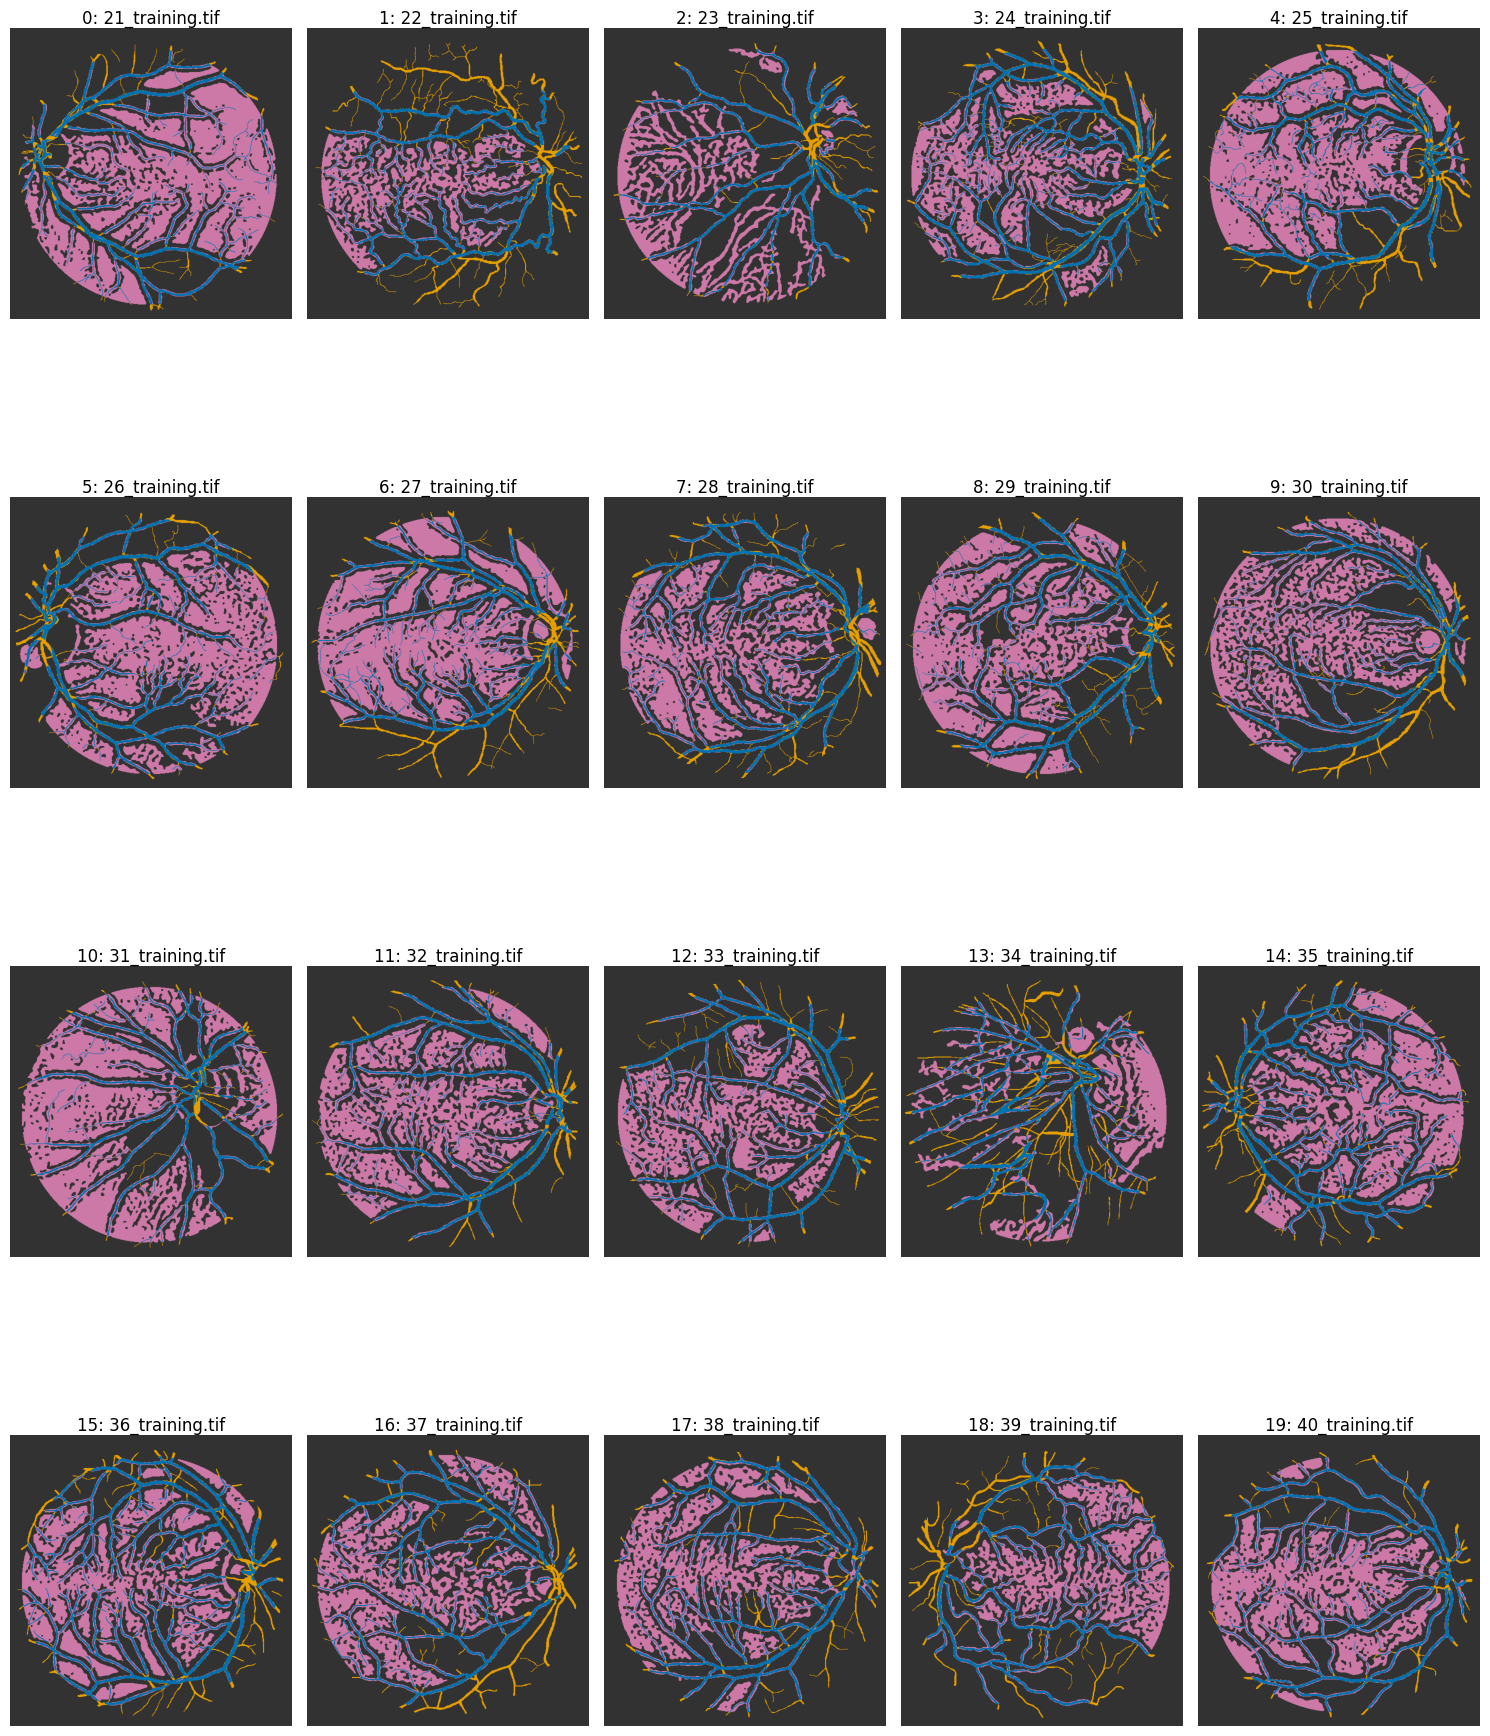

Displaying images: Images


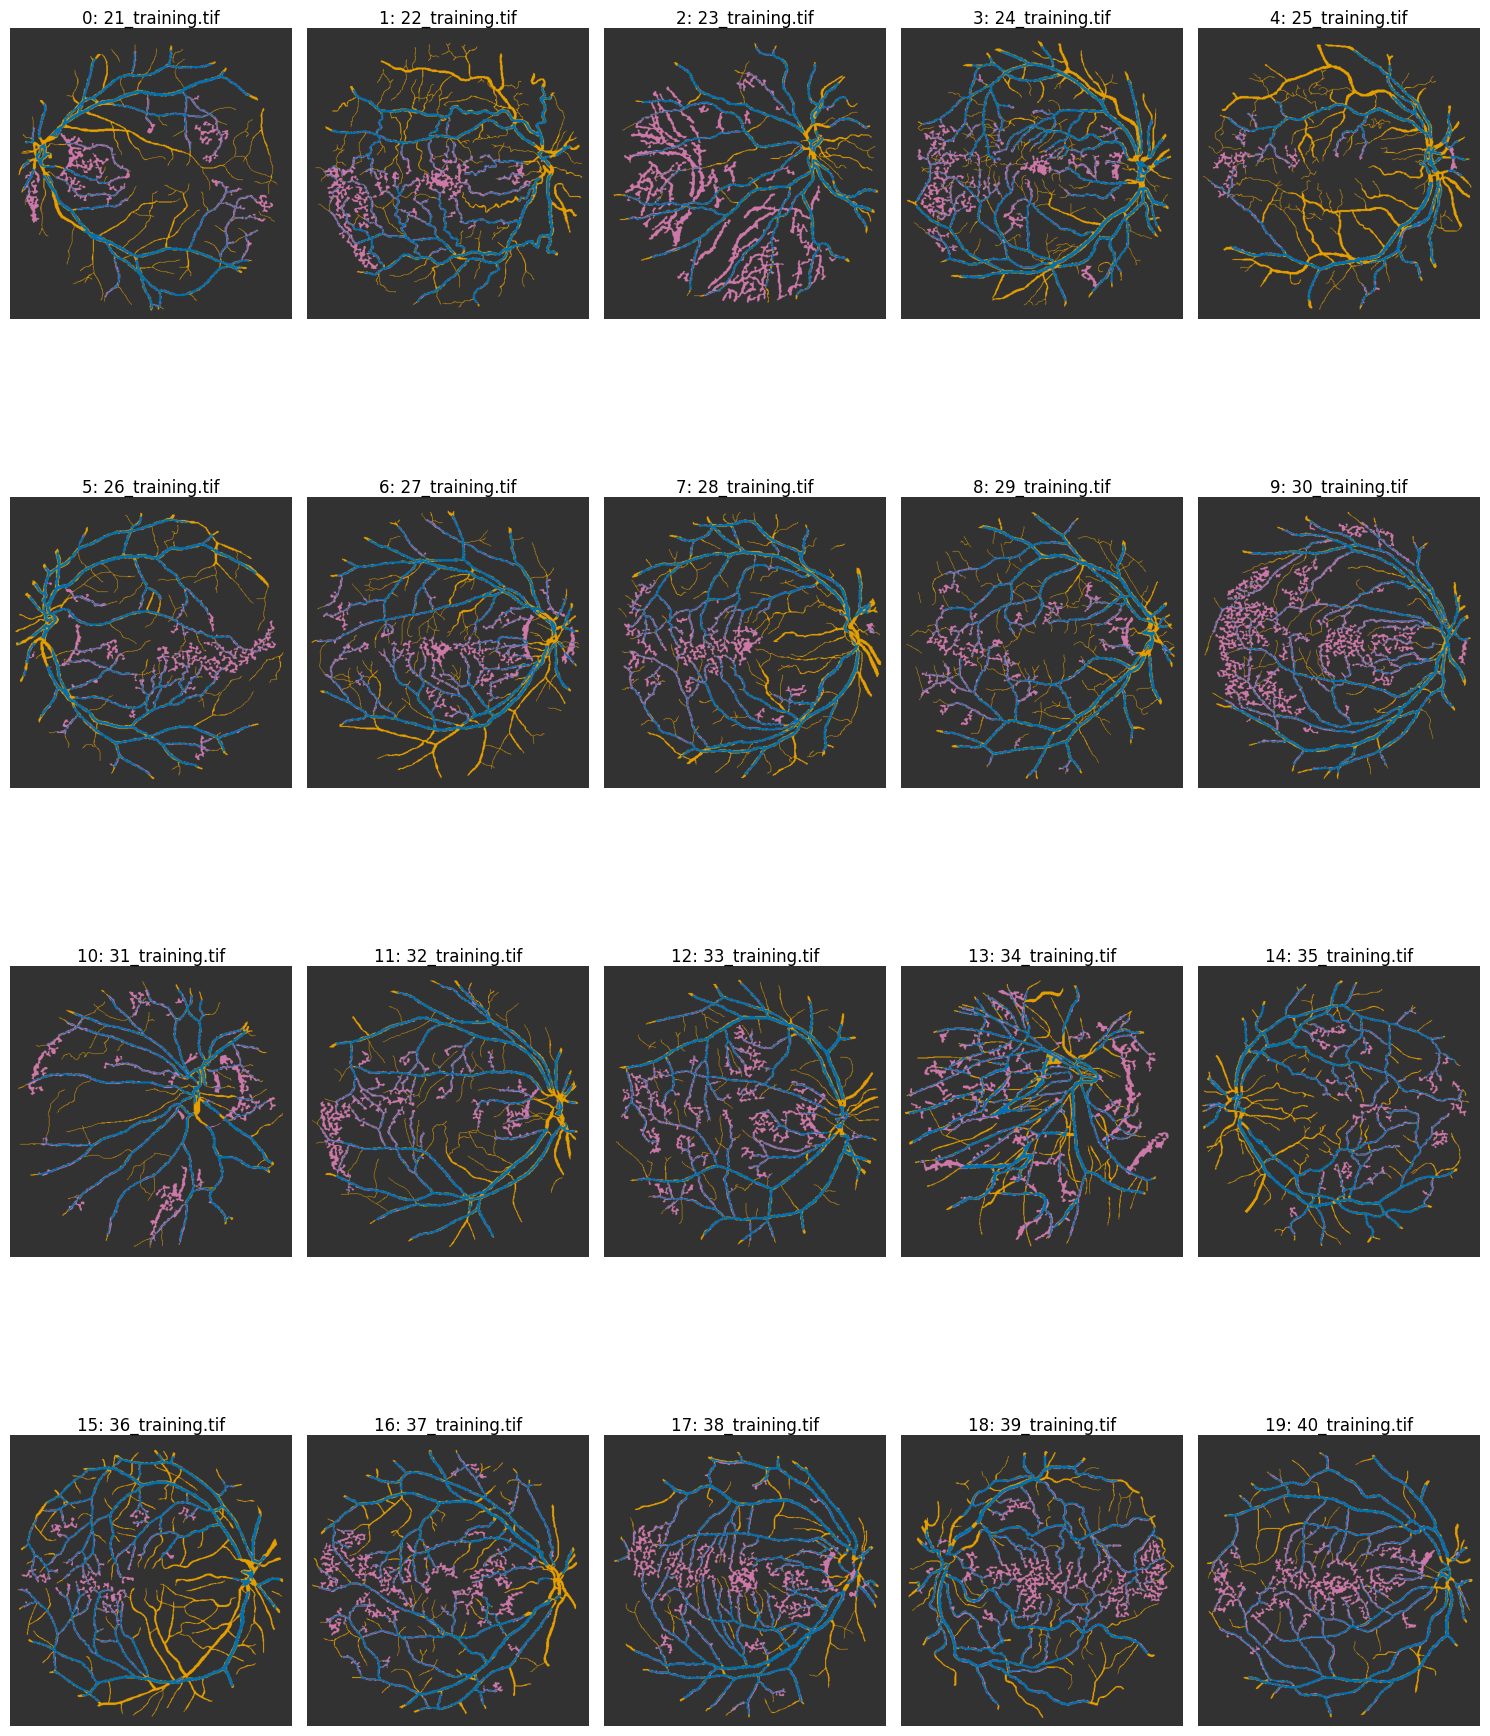

Unoptimized metrics
       Image      Dice       FPR       FNR  Precision    Recall  Accuracy
0    Image_1  0.284951  0.322150  0.171141   0.172050  0.828859  0.689135
1    Image_2  0.412795  0.130554  0.398034   0.314091  0.601966  0.845281
2    Image_3  0.374024  0.164364  0.233485   0.247363  0.766515  0.831086
3    Image_4  0.467731  0.195958  0.238275   0.337478  0.761725  0.799139
4    Image_5  0.322647  0.294092  0.274811   0.207478  0.725189  0.707759
5    Image_6  0.317679  0.298793  0.192398   0.197729  0.807602  0.710098
6    Image_7  0.303330  0.297706  0.270388   0.191465  0.729612  0.704701
7    Image_8  0.388389  0.225169  0.257695   0.262997  0.742305  0.771654
8    Image_9  0.330791  0.278205  0.201434   0.208600  0.798566  0.728252
9   Image_10  0.326886  0.241729  0.249807   0.208971  0.750193  0.757637
10  Image_11  0.249869  0.322426  0.139914   0.146166  0.860086  0.688580
11  Image_12  0.351390  0.250855  0.186518   0.224095  0.813482  0.754407
12  Image_13  0.38

In [11]:
print_error_overlay_legend()
collection.show_images(unoptimized_overlay, image_names, max_images=len(images))
collection.show_images(optimized_overlay, image_names, max_images=len(images))

unoptimized_metrics = compute_segmentation_metrics(unoptimized, vessels)
optimized_metrics = compute_segmentation_metrics(optimized, vessels)

print("Unoptimized metrics")
print(unoptimized_metrics)
print("\nOptimized metrics:")
print(optimized_metrics)

The segmentation pipeline demonstrates notable shifts in performance between its unoptimized and optimized versions. Overall, the optimized model shows substantial improvements across several evaluation metrics, although certain tradeoffs remain—particularly regarding the preservation of fine vascular structures.

One of the most significant improvements is observed in the Dice coefficient, which increases from an average of 0.361 in the unoptimized pipeline to 0.607 after optimization, representing an improvement of approximately 68%. This indicates a substantially better overlap between the predicted vessel regions and the ground truth annotations. Precision also improves considerably, rising from 0.241 to 0.592, suggesting that a much larger proportion of detected vessel pixels are correct and that the optimized pipeline produces fewer false positive detections overall.

The Bayesian-optimized pipeline also achieved an improved overall AUC score relative to the baseline configuration. However, Recall decreased from 0.762 to 0.646, indicating reduced sensitivity to true vessel pixels. This suggests that the optimized parameter configuration favors stricter vessel selection criteria, which improves segmentation precision while simultaneously removing some smaller or lower-contrast vessel structures. Consequently, the optimization introduces a tradeoff between specificity and the preservation of fine vascular detail.

Despite the reduction in Recall, the False Positive Rate (FPR) decreases substantially from 0.235 to 0.044, indicating improved suppression of background noise and spurious detections. Nevertheless, certain images continue to exhibit localized false positive artifacts, particularly in regions with strong texture variation or illumination irregularities. For example, Image 3 retains noticeable spurious detections despite the overall reduction in FPR.

Several challenging images also continue to suffer from incomplete vessel segmentation. Image 16 remains problematic, with the optimized pipeline producing a False Negative Rate (FNR) of 0.461 compared to 0.225 in the unoptimized version, indicating that many vessel pixels remain undetected. Similarly, Image 14, which contains numerous thin and low-contrast vessels, achieves a Recall of only 0.646 after optimization. Although this represents a slight improvement over the baseline result of 0.638, the segmentation still fails to adequately preserve fine vascular branches.

Interestingly, the optimized pipeline does not universally outperform the unoptimized configuration across all images. In some cases, optimization appears to favor conservative vessel detection strategies that improve global metrics while reducing adaptability to specific image characteristics. This suggests that a more adaptive or image-aware optimization strategy may further improve robustness across diverse retinal image conditions.

Lastly, overall Accuracy remains high, increasing from 0.764 in the unoptimized pipeline to 0.929 after optimization. However, due to the strong class imbalance between vessel and background pixels, Accuracy alone is not a reliable indicator of segmentation quality. Therefore, class-sensitive metrics such as Dice coefficient, Precision, Recall, and AUC remain more informative for evaluating retinal vessel segmentation performance.

# Discussion

The performance evaluation of the segmentation pipeline reveals several limitations that warrant further investigation and methodological refinement. One of the primary challenges identified is the tendency of the algorithm to misclassify complex background textures as vascular structures, particularly in retinal images with strong illumination irregularities or high structural variability. This behavior contributes to elevated false positive detections, as observed in image 2, where the unoptimized pipeline achieved more reliable segmentation results than the optimized version. These findings suggest that the optimization process may, in some cases, favor parameter configurations that perform well on the evaluated dataset while reducing robustness to image-specific variability.

A recurring and equally important issue is the incomplete segmentation of the vascular network, particularly for thin or low-contrast vessels. This limitation is clearly demonstrated in image 16, where a substantial portion of the vessel structure remains undetected, resulting in high false negative rates. One likely cause is the aggressive nature of certain post-processing operations, especially cluster filtering stages that remove smaller connected components. Although these operations help suppress noise and reduce false positives, they also increase the risk of eliminating fine vascular branches. Similar behavior is visible in image 14, where small or low-intensity vessels are underrepresented in the final segmentation mask. These observations highlight the need for improved sensitivity to fine-scale vascular features, potentially through adaptive filtering methods or multi-scale vessel enhancement techniques.

An important methodological limitation of the current study is the absence of a strict separation between optimization and evaluation data. The Bayesian optimization procedure was performed directly on the same dataset used for performance assessment, which introduces the possibility of overfitting to the evaluation images. As a result, the reported improvements may partially reflect adaptation to dataset-specific characteristics rather than true generalization performance. A more rigorous experimental setup would involve separating the data into training, validation, and test subsets, where optimization is performed on the training set, parameter selection is guided by validation performance, and final evaluation is conducted exclusively on unseen test data. However, the practical benefit of such a split may be limited by the relatively small size of the dataset used in this study, as dividing the data further could reduce the stability and representativeness of the optimization process. Despite this limitation, evaluating the pipeline on an entirely independent retinal image dataset would provide a much stronger indication of its generalization capability and robustness across varying imaging conditions.

Although K-means clustering has been considered as a potential strategy to improve vessel segmentation, its prior use in related work—such as the study by GeethaRamani and Balasubramanian motivated the exploration of alternative methodologies in order to maintain methodological distinction from existing approaches. Nevertheless, clustering-based techniques remain a promising direction for future work, particularly if incorporated in a more hybrid or adaptive framework.

Another important consideration concerns the structure of the processing pipeline itself. Currently, the segmentation process consists of a fixed sequence of image processing stages applied uniformly to all images. However, not every stage may contribute positively under all imaging conditions. Incorporating the ability to selectively enable or disable specific processing stages during optimization could lead to a more flexible and adaptive pipeline. Such an approach would allow the optimization framework to dynamically determine which transformations are most beneficial for a given image or image category.

A further promising direction involves adapting the parameter configuration to image-specific characteristics. For example, image complexity measures such as Shannon entropy could be used to dynamically adjust processing parameters according to the degree of background irregularity or structural variation present in an image. This entropy-guided strategy may improve robustness in challenging cases, particularly for images exhibiting strong texture variability or illumination artifacts.

Finally, the choice of optimization metric may also significantly influence the resulting segmentation behavior. Although AUC is a robust and widely adopted evaluation measure, it does not fully capture structural properties such as vessel continuity, spatial coherence, or sensitivity to fine vascular branches. Optimizing alternative metrics, such as the Dice coefficient, F1-score, or a weighted composite metric tailored to retinal vessel segmentation, may lead to a more balanced optimization objective and improved qualitative segmentation performance.

In summary, the results demonstrate that the proposed pipeline is capable of substantially improving retinal vessel segmentation performance through Bayesian optimization, particularly in terms of Dice score, precision, and overall segmentation consistency. At the same time, the findings reveal important limitations related to fine vessel preservation, dataset generalization, and sensitivity to image variability. These limitations provide several promising directions for future work, including adaptive processing strategies, alternative optimization objectives, and validation on independent retinal imaging datasets.

# References

1.	GeethaRamani R, Balasubramanian L. Retinal blood vessel segmentation employing image processing and data mining techniques for computerized retinal image analysis. Biocybern Biomed Eng. 2016 Jan 1;36(1):102–18. 
2.	grand-challenge.org [Internet]. [cited 2025 Jul 10]. DRIVE - Grand Challenge. Available from: https://drive.grand-challenge.org/

